In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [113]:
plt.style.use("ggplot")

In [114]:
df = pd.read_csv("ai_student_impact_dataset.csv")
df.head()

,major,study_year,pre_gpa,genai_hours,use_case,prompt_skill,tool_diversity,paid_sub,study_hours,ai_dependency,policy,exam_anxiety,post_gpa,retention_score,burnout,gpa_change
0,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,1,8.13,5,Allowed_With_Citation,6,2.393,86.44,High,-0.025
1,Medical,Junior,3.821,1.12,Ideation,Advanced,5,0,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low,-0.125
2,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,0,10.35,5,Strict_Ban,9,3.499,73.93,Medium,0.101
3,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,0,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium,0.211
4,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,0,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium,0.163


In [115]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns

In [116]:
for cols in categorical_cols:
  print(f"{cols}: {df[cols].unique()}")

major: ['Humanities' 'Medical' 'Business' 'STEM' 'Arts']
study_year: ['Senior' 'Junior' 'Freshman' 'Sophomore' 'Graduate']
use_case: ['Copywriting/Drafting' 'Ideation' 'Summarizing_Reading'
 'Debugging/Troubleshooting' 'Direct_Answer_Generation']
prompt_skill: ['Beginner' 'Advanced' 'Intermediate']
policy: ['Allowed_With_Citation' 'Strict_Ban' 'Actively_Encouraged']
burnout: ['High' 'Low' 'Medium']


# Analysis

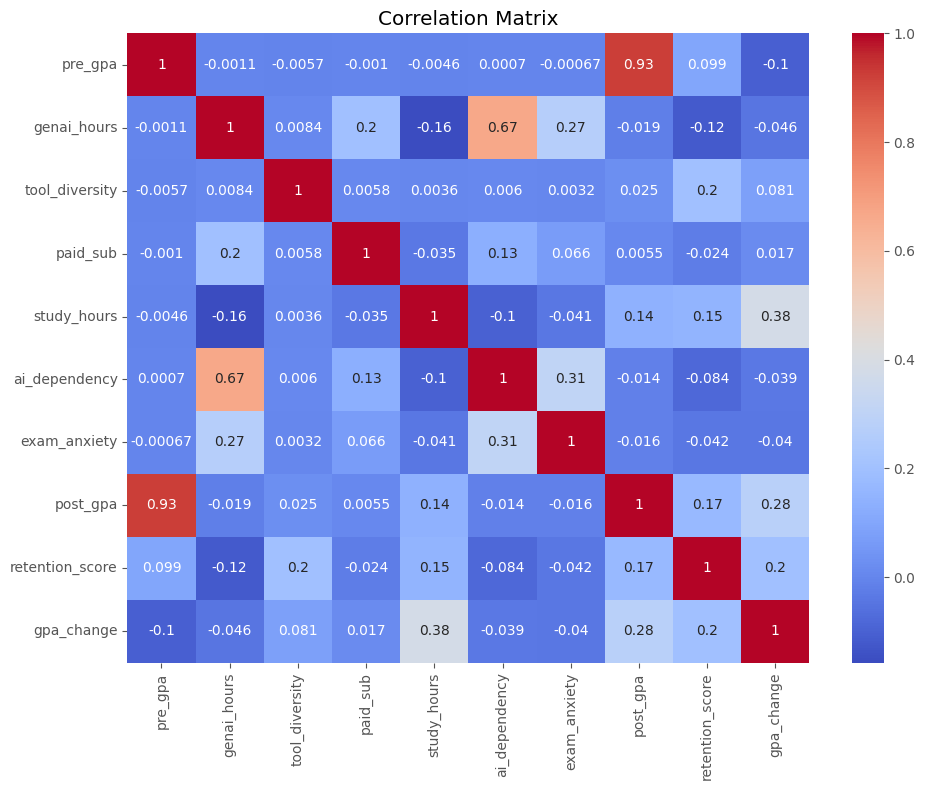

In [117]:
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(corr, annot=True, cmap="coolwarm", ax=ax)

ax.set_title("Correlation Matrix")

plt.tight_layout()
plt.show()

The correlation heatmap shows a strong positive correlation between pre-GPA and post-GPA (r = 0.93), indicating that students with higher initial GPAs tend to maintain higher GPAs. GenAI hours are strongly associated with AI dependency (r = 0.67) and moderately with exam anxiety (r = 0.27). Study hours have a moderate positive relationship with GPA change (r = 0.38), while most other variable pairs show weak or negligible correlations.

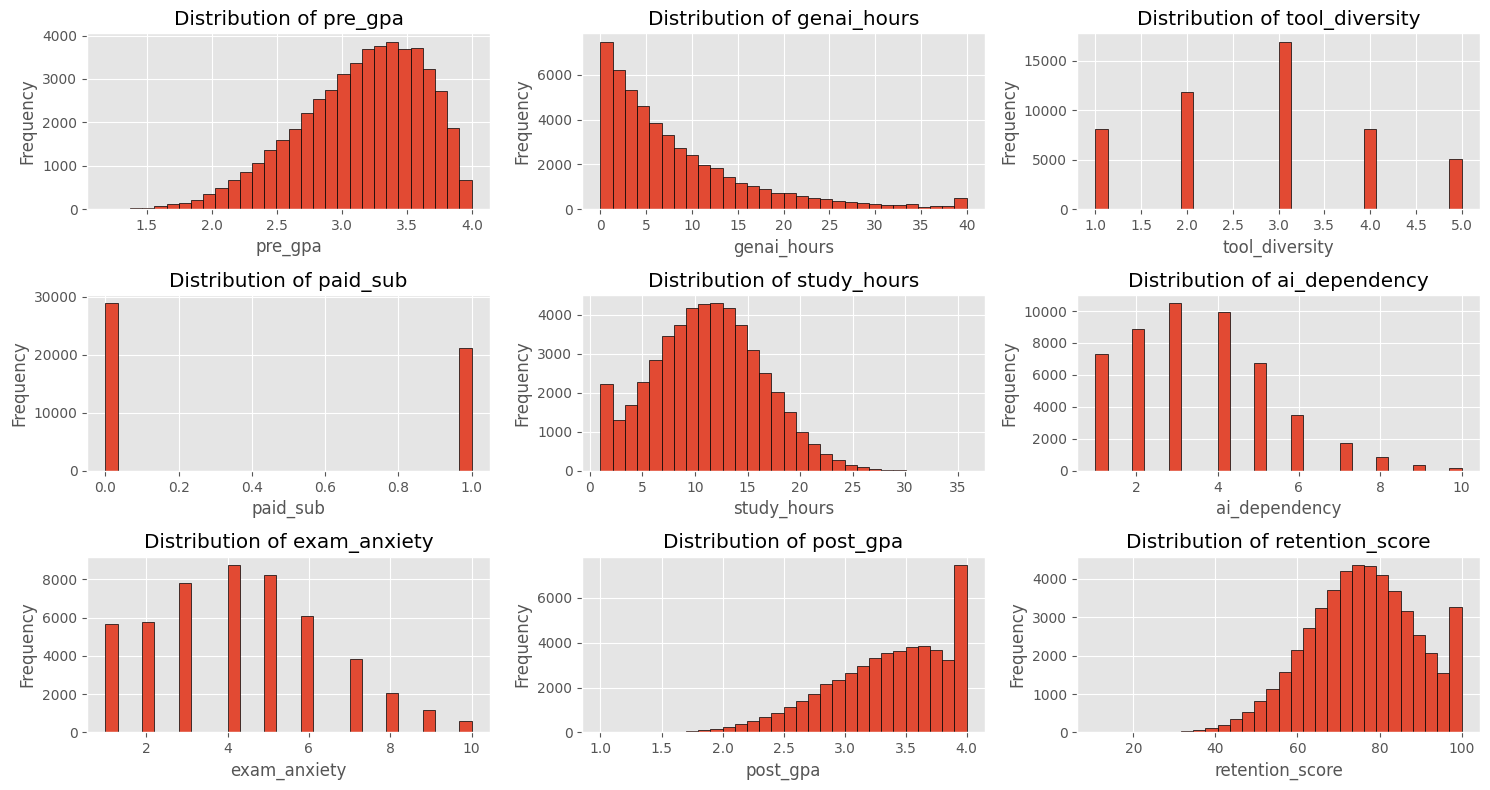

In [118]:
fig, axs = plt.subplots(3,3, figsize=(15,8))
axs = axs.flatten()

for ax, col in zip(axs, numerical_cols):
  ax.hist(df[col], bins=30, edgecolor="black")
  ax.set_title(f"Distribution of {col}")
  ax.set_xlabel(col)
  ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Overall, the distributions show that most students have similar patterns. They generally have high GPAs, study a moderate amount, mostly have no paid subscription and have good retention scores. Most students do not use GenAI heavily, and only a small number have very high AI usage or dependency.

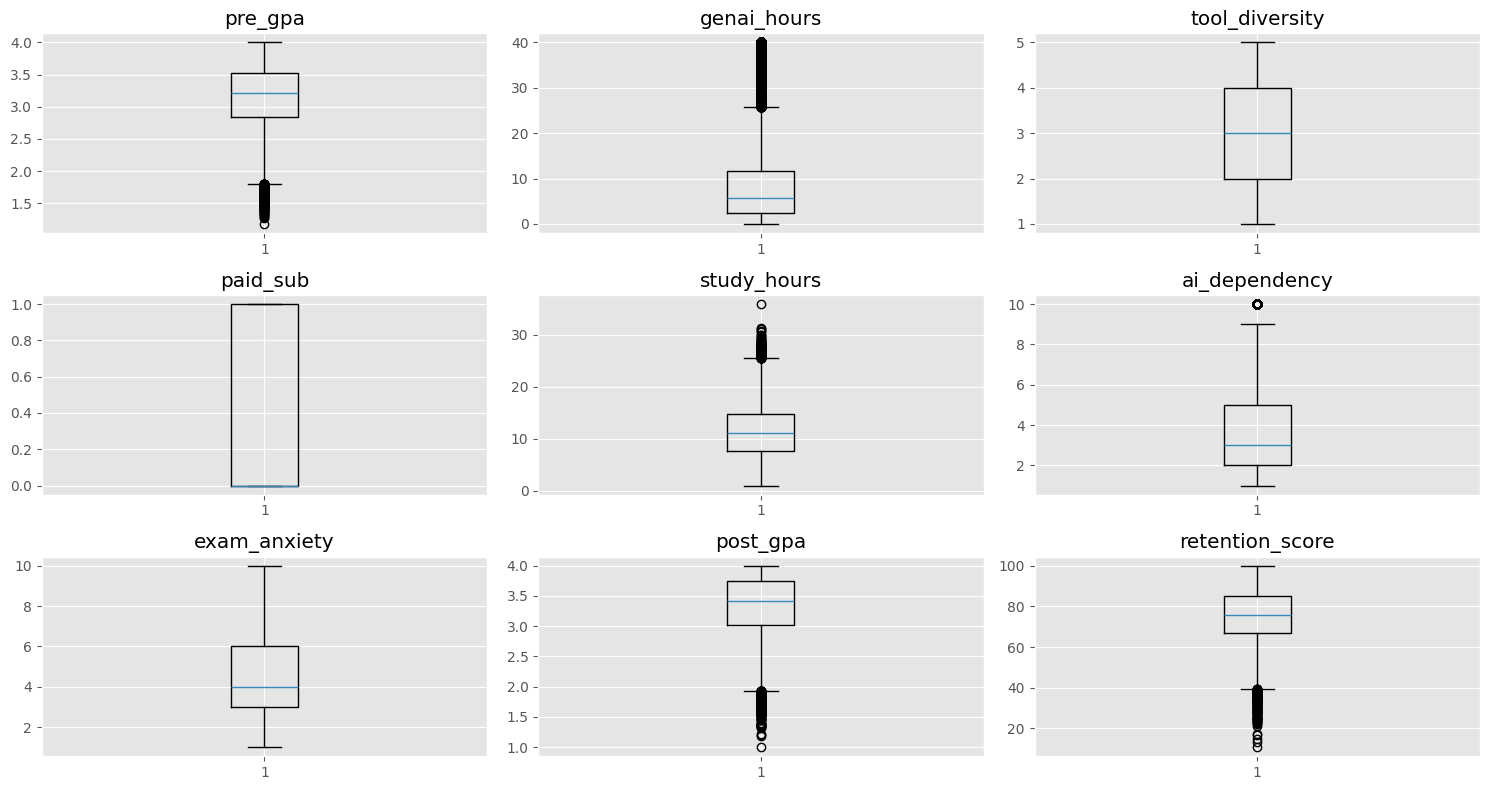

In [119]:
fig, axs = plt.subplots(3,3, figsize=(15,8))
axs = axs.flatten()

for ax, col in zip(axs, numerical_cols):
  ax.boxplot(df[col], vert=True)
  ax.set_title(col)

plt.tight_layout()
plt.show()

The boxplots show that both pre-GPA and post-GPA are generally high, indicating good academic performance among most students. Study hours are higher than GenAI usage hours, suggesting students spend more time studying than using GenAI tools. Retention scores are also relatively high, while tool diversity and AI dependency are mostly at moderate levels across the dataset.

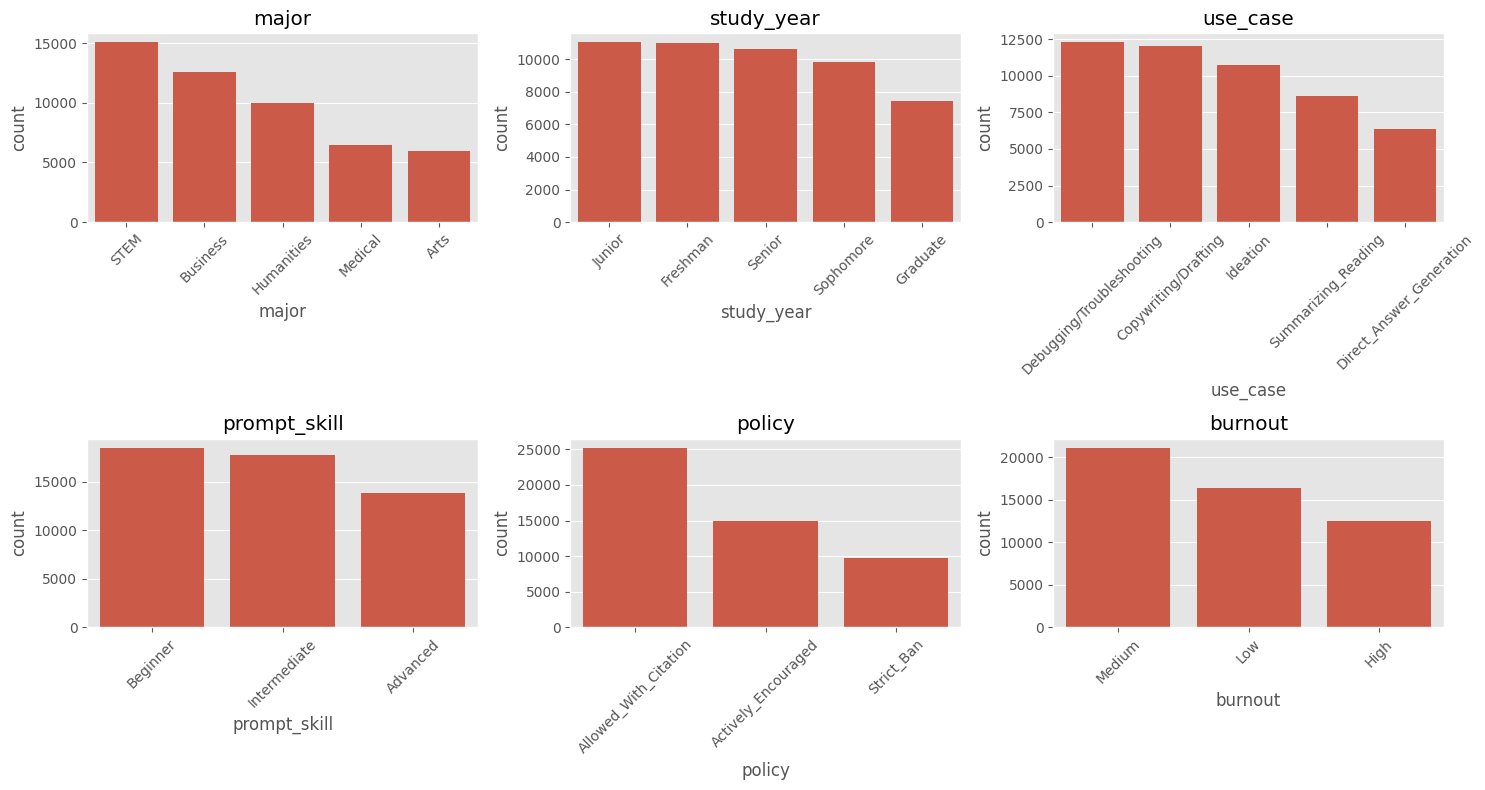

In [120]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()

for ax, col in zip(axs, categorical_cols):
    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index,
        ax=ax
    )
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The bar charts show that STEM has the highest number of students, while Arts has the lowest. Most respondents are Junior and Freshman students, and debugging/troubleshooting and copywriting are the most common GenAI use cases. Most students have beginner or intermediate prompt skills, institutions mainly allow AI with citation, and medium burnout is the most common level.

In [121]:
corr = (
    df.corr(numeric_only=True)["ai_dependency"]
      .sort_values(ascending=False)
)

print("Corr Matrix, ai_dependency\n")
print(corr)

Corr Matrix, ai_dependency

ai_dependency      1.000000
genai_hours        0.665479
exam_anxiety       0.307620
paid_sub           0.131033
tool_diversity     0.006019
pre_gpa            0.000701
post_gpa          -0.014180
gpa_change        -0.039342
retention_score   -0.084324
study_hours       -0.102625
Name: ai_dependency, dtype: float64


AI dependency has the strongest positive correlation with GenAI usage hours (r = 0.665), indicating that students who spend more time using GenAI tend to report higher AI dependency. It also shows a moderate positive relationship with exam anxiety meaning Students with higher AI dependency also tend to report higher exam anxiety, while correlations with GPA, study hours, and retention score are very weak or negligible.

In [122]:
corr = (
    df.corr(numeric_only=True)["gpa_change"]
    .sort_values(ascending=False)
)

print("Corr Matrix, gpa_change\n")
print(corr)

Corr Matrix, gpa_change

gpa_change         1.000000
study_hours        0.376317
post_gpa           0.277146
retention_score    0.195833
tool_diversity     0.081407
paid_sub           0.017265
ai_dependency     -0.039342
exam_anxiety      -0.040420
genai_hours       -0.046479
pre_gpa           -0.104035
Name: gpa_change, dtype: float64


GPA change is most strongly and positively associated with study hours (r = 0.376), indicating that students who study more tend to experience greater GPA improvement. It also has weak positive relationships with post-GPA and retention score, while AI usage and AI dependency show little to no meaningful association with GPA improvement.

In [123]:
corr = (
    df.corr(numeric_only=True)["retention_score"]
    .sort_values(ascending=False)
)

print("Corr Matrix, gpa_change\n")
print(corr)

Corr Matrix, gpa_change

retention_score    1.000000
tool_diversity     0.196952
gpa_change         0.195833
post_gpa           0.169616
study_hours        0.147565
pre_gpa            0.099019
paid_sub          -0.024083
exam_anxiety      -0.041556
ai_dependency     -0.084324
genai_hours       -0.118099
Name: retention_score, dtype: float64


Retention score has a weak positive correlation with tool diversity (r = 0.197) and post_gpa (r = 0.169), suggesting that students who use a wider variety of AI tools tend to retain knowledge slightly better. It shows weak negative relationships with GenAI usage hours (r = −0.118) and AI dependency (r = −0.084), indicating that higher AI usage or reliance is associated with marginally lower knowledge retention.

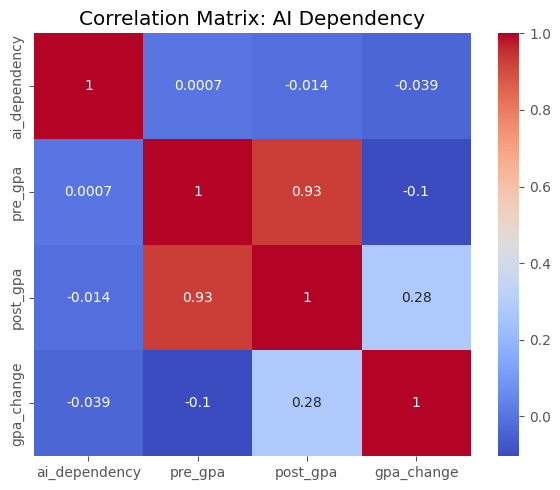

In [124]:
fig, ax = plt.subplots(figsize=(6, 5))

corr1 = df[["ai_dependency", "pre_gpa", "post_gpa", "gpa_change"]].corr()

sns.heatmap(corr1, annot=True, cmap="coolwarm", ax=ax)

ax.set_title("Correlation Matrix: AI Dependency")

plt.tight_layout()
plt.show()

AI dependency has virtually no correlation with pre-GPA, post-GPA, or GPA change, suggesting that higher dependence on AI is not associated with students' academic performance. In contrast, pre-GPA and post-GPA are strongly positively correlated (r = 0.927), indicating that students with higher initial GPAs generally maintain higher GPAs later.

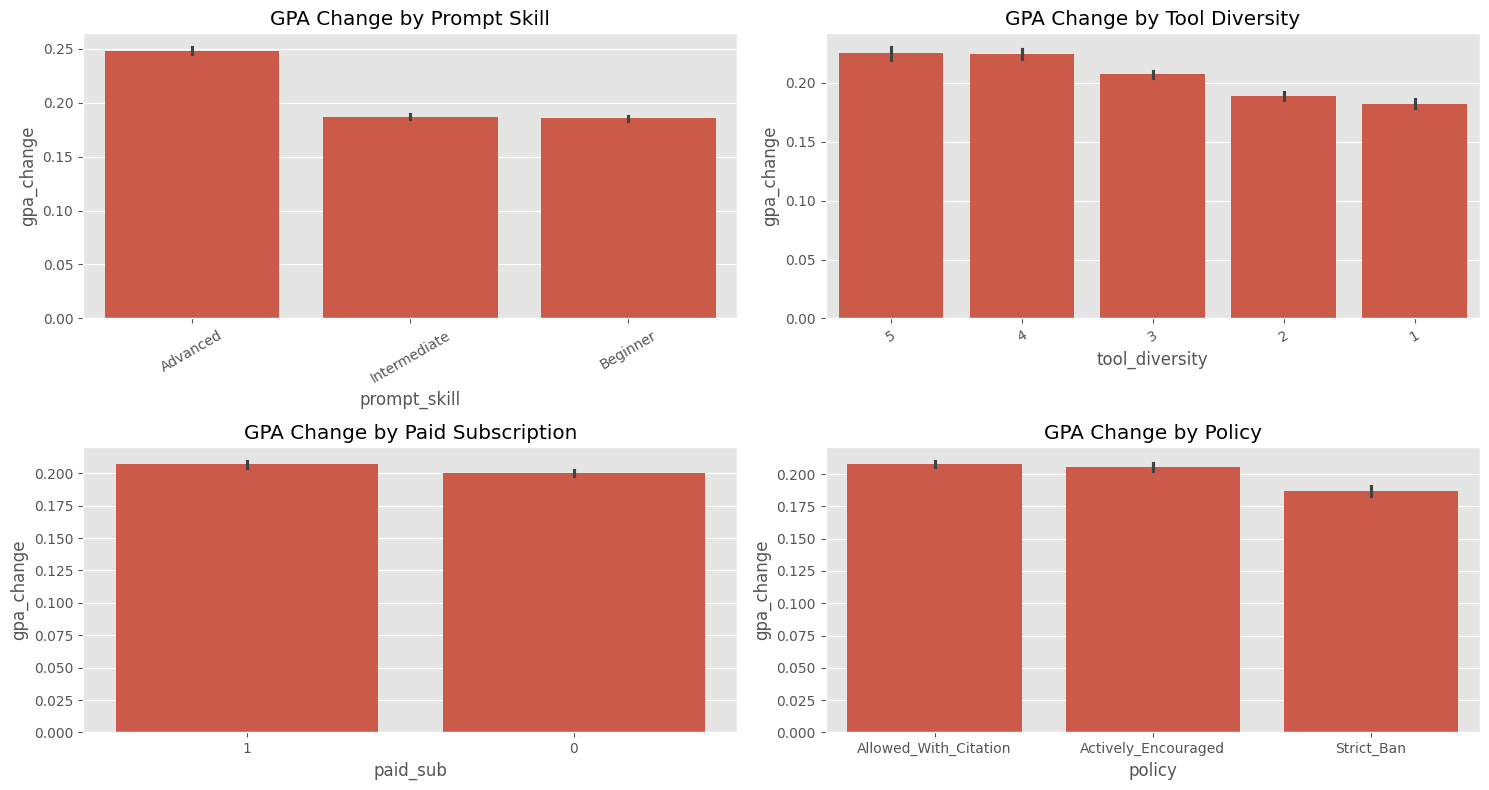

In [125]:
fig, axs = plt.subplots(2, 2, figsize=(15,8))
axs = axs.flatten()

order = df.groupby("prompt_skill")["gpa_change"].mean().sort_values(ascending=False).index
sns.barplot(data=df, x="prompt_skill", y="gpa_change", order=order, ax=axs[0])
axs[0].set_title("GPA Change by Prompt Skill")
axs[0].tick_params(axis='x', rotation=30)

order = df.groupby("tool_diversity")["gpa_change"].mean().sort_values(ascending=False).index
sns.barplot(data=df, x="tool_diversity", y="gpa_change", order=order, ax=axs[1])
axs[1].set_title("GPA Change by Tool Diversity")
axs[1].tick_params(axis='x', rotation=30)

order = df.groupby("paid_sub")["gpa_change"].mean().sort_values(ascending=False).index
sns.barplot(data=df, x="paid_sub", y="gpa_change", order=order, ax=axs[2])
axs[2].set_title("GPA Change by Paid Subscription")

order = df.groupby("policy")["gpa_change"].mean().sort_values(ascending=False).index
sns.barplot(data=df, x="policy", y="gpa_change", order=order, ax=axs[3])
axs[3].set_title("GPA Change by Policy")

plt.tight_layout()
plt.show()

**1. Prompt skill** : The plot shows that participants with advanced prompt skills achieved the greatest average GPA improvement (about 0.25), while beginner and intermediate groups showed similar, lower improvements (around 0.19).


**2. Tool Diversity**: The plot indicates a positive relationship between tool diversity and GPA improvement, with average GPA gains increasing as tool diversity rises from 1 to 5. The highest improvements are observed at tool diversity levels 4 and 5, suggesting that using a wider variety of tools is associated with better academic performance.


**3. Paid subscription**: The plot shows that users with a paid subscription experienced a slightly higher average GPA improvement (about 0.21) than those without a paid subscription (about 0.20).


**4. Policy**: Students in institutions where generative AI is allowed with citation show the highest average GPA change (0.208), followed by those where AI is actively encouraged (0.206). Institutions with a strict ban have the lowest average GPA change (0.187), suggesting that more permissive AI policies are associated with slightly higher GPA improvements.

In [126]:
print(f"{df.groupby("paid_sub")["genai_hours"].mean()}\n")

paid_sub
0     7.033095
1    10.329533
Name: genai_hours, dtype: float64



The results indicate that users without a paid AI subscription use generative AI for an average of 7.03 hours, whereas users with a paid subscription use it for an average of 10.33 hours.

In [127]:
print(f"{df.groupby("major")["genai_hours"].mean().sort_values(ascending=False)}\n")

print(df.groupby("major")[["pre_gpa", "post_gpa","gpa_change"]].mean().sort_values(by="gpa_change", ascending=False))

major
STEM          10.488609
Business       8.275898
Medical        7.546728
Arts           7.271702
Humanities     6.770144
Name: genai_hours, dtype: float64

             pre_gpa  post_gpa  gpa_change
major                                     
STEM        3.145852  3.363154    0.217302
Medical     3.151769  3.353168    0.201399
Humanities  3.147850  3.345825    0.197976
Arts        3.146786  3.343688    0.196902
Business    3.141760  3.336085    0.194325


The results show that STEM students spent the most time using generative AI (10.49 hours) and achieved the largest average GPA improvement (0.217). While all majors experienced GPA gains after using generative AI, Business students had the lowest average improvement (0.194), suggesting that greater AI usage may be associated with slightly higher academic performance depending on majors.

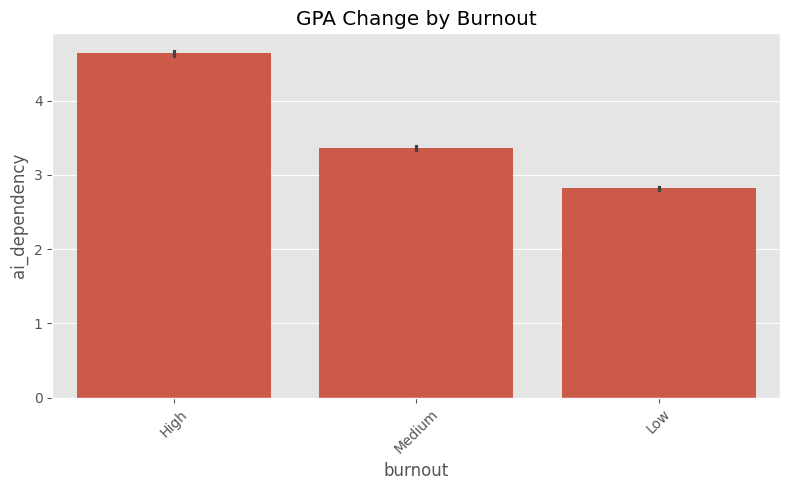

In [128]:
order = (df.groupby("burnout")["ai_dependency"].mean().sort_values(ascending=False).index
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(data=df, x="burnout", y="ai_dependency", order=order, ax=ax
)

ax.set_title("GPA Change by Burnout")
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The plot shows that students with high burnout reported the highest average AI dependency (about 4.7), followed by those with medium burnout (about 3.4), while students with low burnout had the lowest AI dependency (about 2.8).

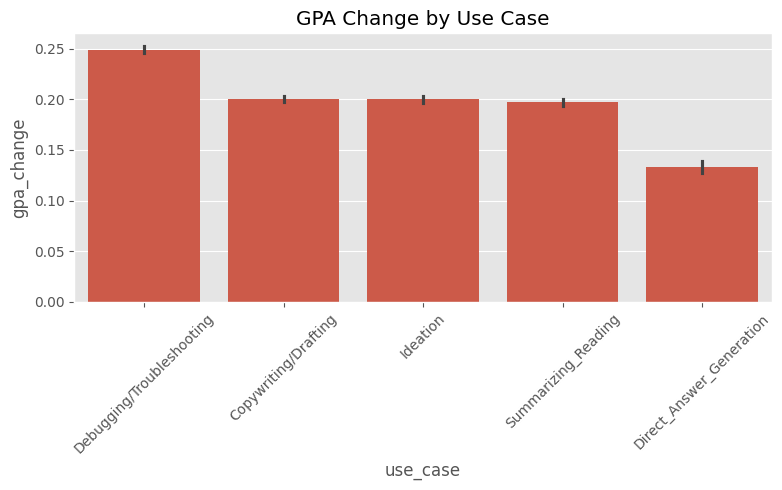

In [129]:
order = (df.groupby("use_case")["gpa_change"].mean().sort_values(ascending=False).index
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(data=df, x="use_case", y="gpa_change", order=order, ax=ax
)

ax.set_title("GPA Change by Use Case")
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

fig.savefig(
    "gpa_change_by_usecases.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The plot shows that students using AI for Debugging/Troubleshooting achieved the highest average GPA improvement (r = 0.25), while those using it for Direct Answer Generation had the lowest improvement (about 0.13).